In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

import ssqueezepy as sq

## White noise - CWT coefficients are flat for L2 norm, and grow as sqrt(f) for L1 norm

In [24]:
n = 50_000
dt = 0.01 # s
fs = 1/dt

x = np.random.randn(n)
t = np.arange(n)*dt

## L1 norm, default

In [25]:
wav = sq.Wavelet(('morlet', {'mu': 13.4}))
W, scales = sq.cwt(x, wavelet=wav, l1_norm=True, )
freqs = sq.experimental.scale_to_freq(scales, wav, n, fs)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.QuadMesh at 0x341452f90>)

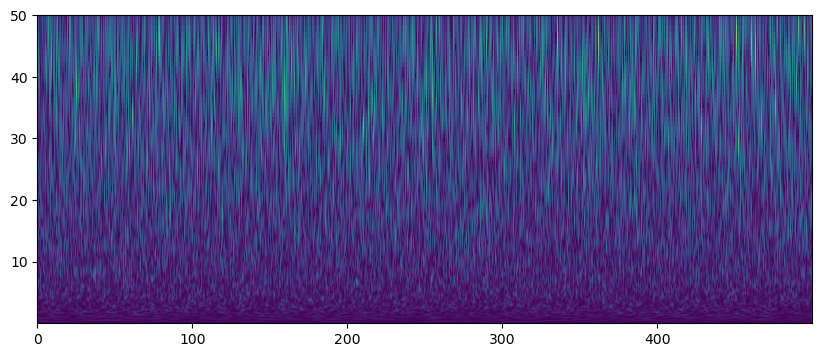

In [26]:
wf.plot_cwt(abs(W), freqs, t)

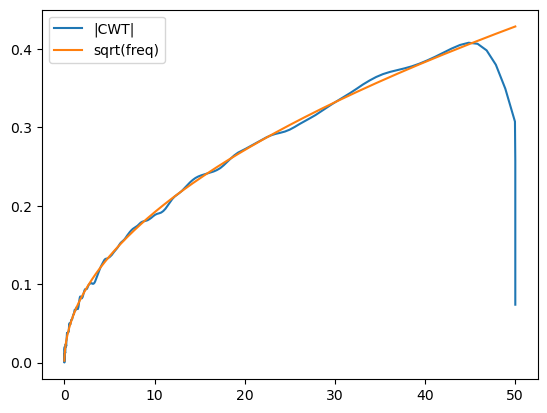

In [27]:
y = abs(W).mean(axis=1)

plt.plot(freqs, y, label='|CWT|')
plt.plot(freqs, np.sqrt(freqs)/16.5, label='sqrt(freq)')
plt.legend()
# plt.xscale('log')

## L2 norm

In [28]:
wav = sq.Wavelet(('morlet', {'mu': 13.4}))
W, scales = sq.cwt(x, wavelet=wav, l1_norm=False)
freqs = sq.experimental.scale_to_freq(scales, wav, n, fs)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.QuadMesh at 0x34154e9d0>)

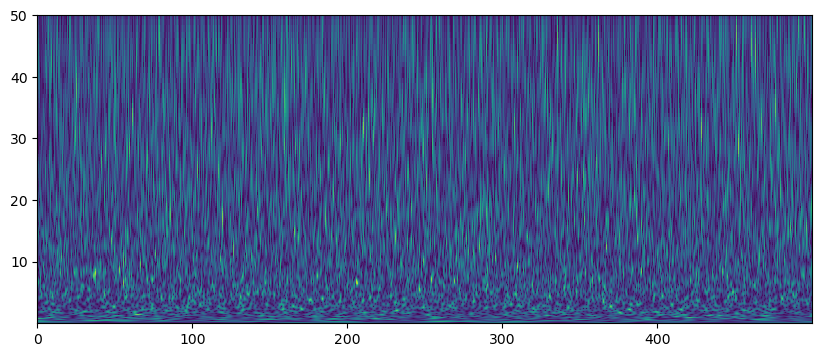

In [29]:
wf.plot_cwt(abs(W), freqs, t)

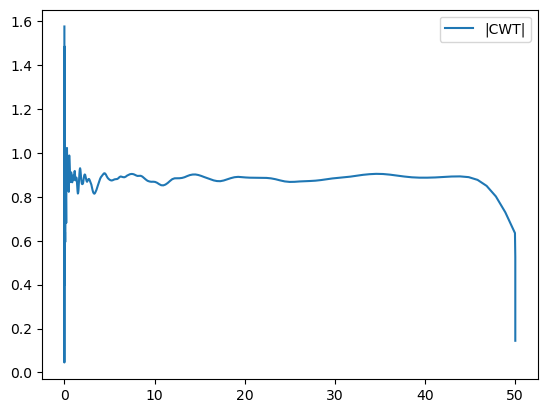

In [30]:
y = abs(W).mean(axis=1)

plt.plot(freqs, y, label='|CWT|')
# plt.plot(freqs, x.std(), label='sqrt(freq)')
# plt.axhline(x.std(), ls='--', label='Signal STD', color='k')
plt.legend()
# plt.xscale('log')

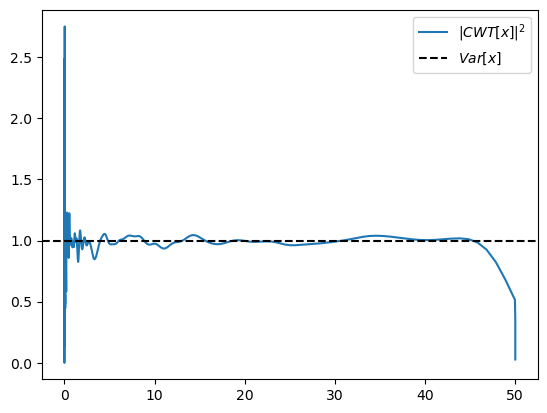

In [35]:
y = (abs(W)**2).mean(axis=1)

plt.plot(freqs, y, label='$|CWT[x]|^2$')
# plt.plot(freqs, x.std(), label='sqrt(freq)')
plt.axhline(x.std()**2, ls='--', label='$Var[x]$', color='k')
plt.legend()
# plt.xscale('log')

## Wavelet power of white noise should equal the noise's variance, for L2 normalization. It looks to be so for ssqueezepy's cwt with l1_norm=False

## - Coefficients at low frequency are more noisy, naturally, because the signal duration is fixed for all frequencies, but wavelet width (timespan) is larger for low frequencies, hence there's less information about low frequencies than about high.

## - Coefficients drop for high frequency (approaching Nyquist). MATLAB implementation makes maximal frequency lower than Nyquist.